## Model 001 Review Checklist (Return Plan)

## Key Goal

Train and evaluate a regression baseline for helpful-vote prediction.

## Decision It Supports

Whether tabular regression signals outperform dumb baselines with acceptable generalization gap.

## Primary Metrics

RMSE, MAE, R2 (train/validation), plus baseline comparison deltas.


## Section Index

1. Setup and imports
2. Data loading
3. Metric helpers
4. Data sanity checks
5. Baseline predictors, then full linreg + `metrics_compare`
6. Residual / error diagnostics
7. Three-feature restricted model (artifact → fit → **Train** → save → residuals → coef; `metrics_compare_3feat`)
8. Metric evaluation — combined table + charts (all models)
9. Export metrics CSV

## 1) Setup and Imports

In [35]:
import sys
from pathlib import Path


def _repo_root() -> Path:
    """Package outputs under repo `artifacts/` regardless of notebook kernel cwd."""
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "pyproject.toml").is_file():
            return d
    raise RuntimeError(
        "Could not find repo root (no pyproject.toml). "
        f"cwd={here}"
    )


REPO_ROOT = _repo_root()

import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump


# Repo `src/` on path (use `pip install -e .` from repo root if you prefer)
_src = REPO_ROOT / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from sklearn.linear_model import LinearRegression

from steam_review_ml.evaluation import regression_metrics

METRIC_FILENAME = "votes_helpful_metrics.csv"

## 2) Data Loading

In [2]:
# load training data as pandas dataframe
df_train = pd.read_parquet(REPO_ROOT / "data/processed/steam_reviews_cleaned_english_train_norm.parquet")
df_val = pd.read_parquet(REPO_ROOT / "data/processed/steam_reviews_cleaned_english_val_norm.parquet")

## 3) Metric Helpers

In [3]:
# Metrics: see `steam_review_ml.evaluation.regression_metrics` (shared with model_000 dumb baselines).


## 4) Data Sanity Checks

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df_train.head()

,review_id,app_id,app_name,author.steamid,review,recommended,votes_helpful,author.num_games_owned,author.num_reviews,author.playtime_last_two_weeks,author.playtime_at_review,steam_purchase,received_for_free,written_during_early_access,timestamp_created,author.last_played,is_helpful,review_word_count,review_length_chars,review_age_seconds,_norm_votes_helpful,_norm_author__playtime_last_two_weeks,_norm_author__playtime_at_review,_norm_author__num_games_owned,_norm_author__num_reviews,_norm_review_word_count
0,85184605,292030,The Witcher 3: Wild Hunt,76561199054755373,"One of the best RPG's of all time, worthy of a...",1,0,5,3,3200.0,5524.0,1,0,0,1611379970,1.611384e+09,0,12,59,45121.0,0.0,8.071219,8.617039,1.791759,1.386294,2.564949
1,85184171,292030,The Witcher 3: Wild Hunt,76561198170193529,"good story, good graphics. lots to do.",1,0,11,1,823.0,823.0,1,0,0,1611379264,1.611379e+09,0,7,38,45827.0,0.0,6.714171,6.714171,2.484907,0.693147,2.079442
2,85184064,292030,The Witcher 3: Wild Hunt,76561198119302812,"dis gud,",1,0,27,2,3398.0,4192.0,1,0,0,1611379091,1.611352e+09,0,2,8,46000.0,0.0,8.131237,8.341172,3.332205,1.098612,1.098612
3,85180436,292030,The Witcher 3: Wild Hunt,76561198065591528,favorite game of all time cant wait for the Ne...,1,0,33,1,177.0,23329.0,1,0,0,1611373086,1.611219e+09,0,11,59,52005.0,0.0,5.181784,10.057495,3.526361,0.693147,2.484907
4,85179753,292030,The Witcher 3: Wild Hunt,76561198996835044,Why wouldn't you get this,1,0,131,2,2004.0,8557.0,1,0,0,1611371978,1.611371e+09,0,5,25,53113.0,0.0,7.603399,9.054622,4.882802,1.098612,1.791759


In [6]:
df_train.columns

Index(['review_id', 'app_id', 'app_name', 'author.steamid', 'review',
       'recommended', 'votes_helpful', 'author.num_games_owned',
       'author.num_reviews', 'author.playtime_last_two_weeks',
       'author.playtime_at_review', 'steam_purchase', 'received_for_free',
       'written_during_early_access', 'timestamp_created',
       'author.last_played', 'is_helpful', 'review_word_count',
       'review_length_chars', 'review_age_seconds', '_norm_votes_helpful',
       '_norm_author__playtime_last_two_weeks',
       '_norm_author__playtime_at_review', '_norm_author__num_games_owned',
       '_norm_author__num_reviews', '_norm_review_word_count'],
      dtype='str')

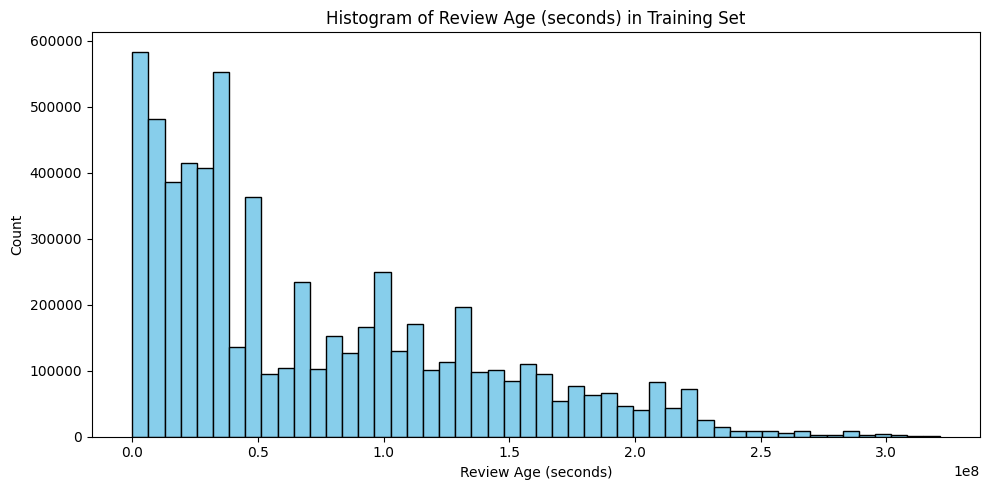

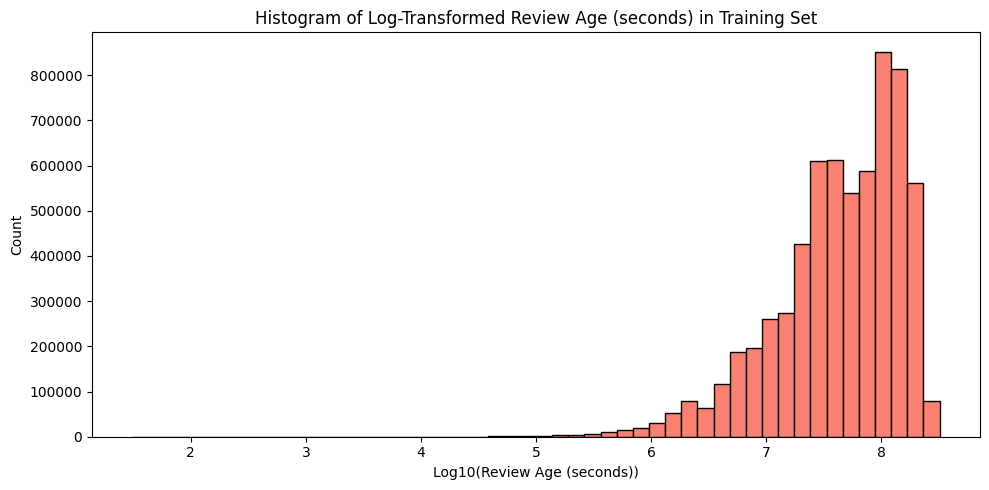

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Linear scale histogram
plt.figure(figsize=(10, 5))
plt.hist(df_train["review_age_seconds"], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Review Age (seconds)")
plt.ylabel("Count")
plt.title("Histogram of Review Age (seconds) in Training Set")
plt.tight_layout()
plt.show()

# Log scale histogram
plt.figure(figsize=(10, 5))
field = df_train["review_age_seconds"]
field_nonzero = field[field > 0]  # Log cannot handle zero
plt.hist(np.log10(field_nonzero), bins=50, color='salmon', edgecolor='black')
plt.xlabel("Log10(Review Age (seconds))")
plt.ylabel("Count")
plt.title("Histogram of Log-Transformed Review Age (seconds) in Training Set")
plt.tight_layout()
plt.show()

## 5) Modeling and Evaluation

### Baseline predictors (`_norm_votes_helpful`)

Dumb baselines aligned with `model_000_baseline_dumb`: **all zero**, **train mean**, and **empirical random** (sample train labels with replacement using the train empirical PMF). Computed here **before** fitting the full linear model so the **Full Dataset Model** section can focus on `linreg` only.


In [8]:
SEED = 2026
# Match model_000_baseline_dumb: votes baselines use np.random.default_rng(SEED + 3).
rng_emp = np.random.default_rng(SEED + 3)

vt = df_train["_norm_votes_helpful"].astype(float)
mean_helpful = float(vt.mean())
value_probs = vt.value_counts(normalize=True).sort_index()
emp_values = value_probs.index.to_numpy()
emp_probs = value_probs.to_numpy()

baseline_zero_tr = np.zeros(len(df_train), dtype=float)
baseline_zero_va = np.zeros(len(df_val), dtype=float)

baseline_mean_tr = np.full(len(df_train), mean_helpful, dtype=float)
baseline_mean_va = np.full(len(df_val), mean_helpful, dtype=float)

baseline_emp_tr = rng_emp.choice(emp_values, size=len(df_train), p=emp_probs).astype(float)
baseline_emp_va = rng_emp.choice(emp_values, size=len(df_val), p=emp_probs).astype(float)


## 6) Full Dataset Model

In [9]:
LINEAR_REGRESSION_MODEL_NAME = "votes_helpful_linreg_full_dataset.pkl"

In [10]:
# instantiate linear regression model
linreg = LinearRegression()

# Use train-fitted normalization columns for numerics that have them; keep raw
# for booleans, timestamps, review_length_chars (no _norm rule in pipeline).
training_cols = [
    '_norm_author__num_games_owned',
    '_norm_author__num_reviews',
    '_norm_author__playtime_last_two_weeks',
    '_norm_author__playtime_at_review',
    'steam_purchase', 'received_for_free',
    'written_during_early_access', 'timestamp_created',
    'author.last_played', 'review_length_chars',
    '_norm_review_word_count',
]
linreg.fit(
    X=df_train[training_cols],
    y=df_train['_norm_votes_helpful'],
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Train

In [11]:
# Linreg predictions + metrics table (baselines computed above)
df_train["_norm_votes_helpful_pred"] = linreg.predict(df_train[training_cols])
df_val["_norm_votes_helpful_pred"] = linreg.predict(df_val[training_cols])

pred_rows = [
    ("all_zero", baseline_zero_tr, baseline_zero_va),
    ("train_mean", baseline_mean_tr, baseline_mean_va),
    ("empirical_random", baseline_emp_tr, baseline_emp_va),
]
lin_tr = df_train["_norm_votes_helpful_pred"].to_numpy(dtype=float)
lin_va = df_val["_norm_votes_helpful_pred"].to_numpy(dtype=float)
pred_rows.append(("linreg_full_dataset", lin_tr, lin_va))

y_tr = df_train["_norm_votes_helpful"].to_numpy(dtype=float)
y_va = df_val["_norm_votes_helpful"].to_numpy(dtype=float)

table_rows = []
for name, p_tr, p_va in pred_rows:
    tr = regression_metrics(y_tr, p_tr)
    va = regression_metrics(y_va, p_va)
    row = {"model": name}
    for k, v in tr.items():
        row[f"train_{k}"] = v
    for k, v in va.items():
        row[f"val_{k}"] = v
    table_rows.append(row)

metrics_compare = pd.DataFrame(table_rows)
numeric_cols = [c for c in metrics_compare.columns if c != "model"]
for c in numeric_cols:
    if c.startswith("val_"):
        k = c.replace("val_", "", 1)
        tc = f"train_{k}"
        if tc in metrics_compare.columns:
            metrics_compare[f"gap_{k}"] = metrics_compare[c] - metrics_compare[tc]

metrics_compare


/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/nump

,model,train_mae,train_mse,train_rmse,train_r2,train_mape_pct,train_spearman_rho,val_mae,val_mse,val_rmse,val_r2,val_mape_pct,val_spearman_rho,gap_mae,gap_mse,gap_rmse,gap_r2,gap_mape_pct,gap_spearman_rho
0,all_zero,0.318910,0.444921,0.667024,-0.296325,2.988793e+01,NaN,0.318993,0.445528,0.667479,-2.960006e-01,2.987633e+01,NaN,0.000083,0.000607,0.000455,3.244519e-04,-1.159781e-02,NaN
1,train_mean,0.447189,0.343217,0.585848,0.000000,2.235947e+09,NaN,0.447346,0.343772,0.586320,-1.987587e-08,2.236317e+09,NaN,0.000157,0.000554,0.000473,-1.987587e-08,3.698662e+05,NaN
2,empirical_random,0.495788,0.686687,0.828666,-1.000736,2.234892e+09,0.000003,0.495974,0.685874,0.828175,-9.951428e-01,2.236034e+09,-0.001435,0.000186,-0.000814,-0.000491,5.592866e-03,1.141814e+06,-0.001438
3,linreg_full_dataset,0.401852,0.307131,0.554194,0.105142,2.000357e+09,0.302910,0.402217,0.307647,0.554659,1.050843e-01,2.002613e+09,0.301636,0.000365,0.000516,0.000465,-5.725168e-05,2.256252e+06,-0.001273


In [12]:
# Save fitted model only. Metrics CSV is written last and reuses `metrics_compare_all`
# from the Metric evaluation section when that cell has been run.
artifacts_root = REPO_ROOT / "artifacts"
model_dir = artifacts_root / "models" / "tabular"
model_dir.mkdir(parents=True, exist_ok=True)

model_bundle = {
    "estimator": linreg,
    "feature_columns": training_cols,
    "target": "_norm_votes_helpful",
}
model_path = model_dir / LINEAR_REGRESSION_MODEL_NAME
dump(model_bundle, model_path)
print(f"Saved model bundle -> {model_path}")


Saved model bundle -> /home/ryanr/workspace/steam_recommendations/artifacts/models/votes_helpful_linreg_full_dataset.pkl


### Residual and Error Diagnostics

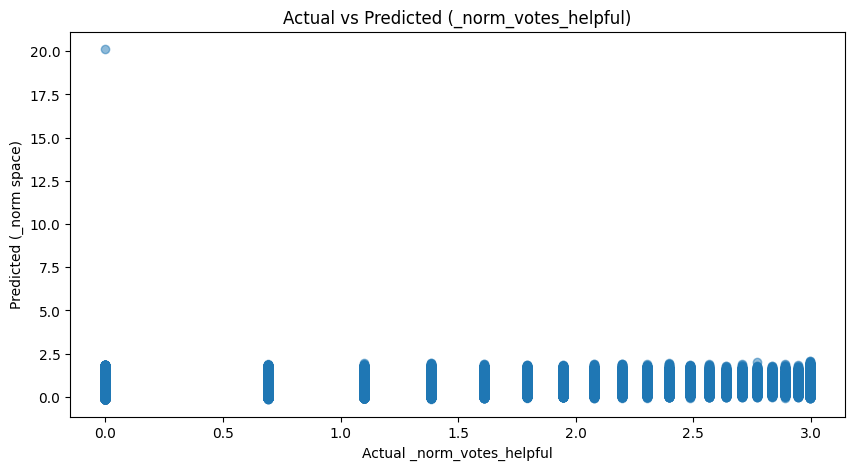

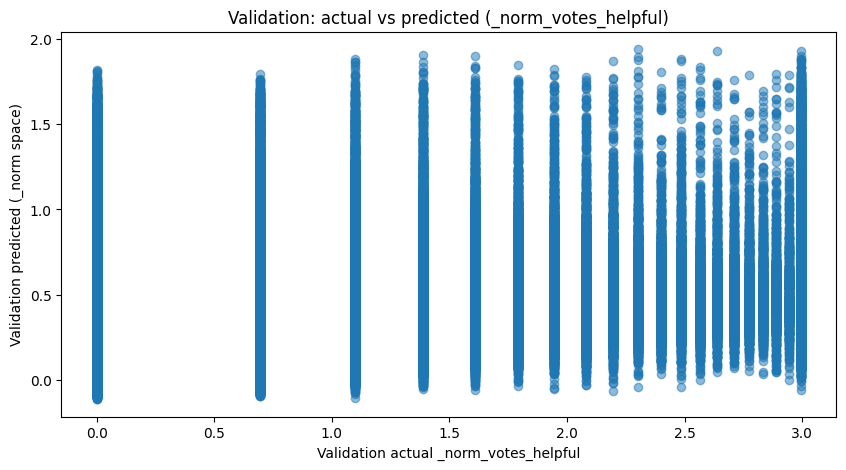

In [13]:
# plot actual vs predicted (normalized target space)
plt.figure(figsize=(10, 5))
plt.scatter(
    df_train["_norm_votes_helpful"],
    df_train["_norm_votes_helpful_pred"],
    alpha=0.5,
)
plt.xlabel("Actual _norm_votes_helpful")
plt.ylabel("Predicted (_norm space)")
plt.title("Actual vs Predicted (_norm_votes_helpful)")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(
    df_val["_norm_votes_helpful"],
    df_val["_norm_votes_helpful_pred"],
    alpha=0.5,
)
plt.xlabel("Validation actual _norm_votes_helpful")
plt.ylabel("Validation predicted (_norm space)")
plt.title("Validation: actual vs predicted (_norm_votes_helpful)")
plt.show()


In [14]:
# Find the record in df_train with the highest predicted votes_helpful (in normalized space)
max_pred_idx = df_train["_norm_votes_helpful_pred"].idxmax()
max_pred_record = df_train.loc[max_pred_idx]
print("Record with highest _norm_votes_helpful_pred in df_train:")
print(max_pred_record)
# print(max_pred_record['review'])

Record with highest _norm_votes_helpful_pred in df_train:
review_id                                                                         33702432
app_id                                                                              379720
app_name                                                                              DOOM
author.steamid                                                           76561198320925817
review                                   [list][list][list][/list][/list][/list] \n[quo...
recommended                                                                              0
votes_helpful                                                                            0
author.num_games_owned                                                                 103
author.num_reviews                                                                      10
author.playtime_last_two_weeks                                                         0.0
author.playtime_at_review       

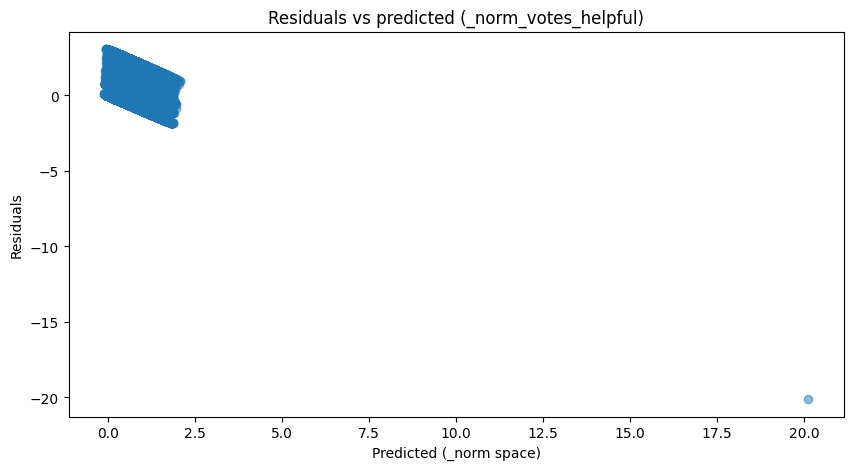

In [15]:
# plot residuals (_norm_votes_helpful - pred)
plt.figure(figsize=(10, 5))
plt.scatter(
    df_train['_norm_votes_helpful_pred'],
    df_train['_norm_votes_helpful'] - df_train['_norm_votes_helpful_pred'],
    alpha=0.5,
)
plt.xlabel('Predicted (_norm space)')
plt.ylabel('Residuals')
plt.title('Residuals vs predicted (_norm_votes_helpful)')
plt.show()

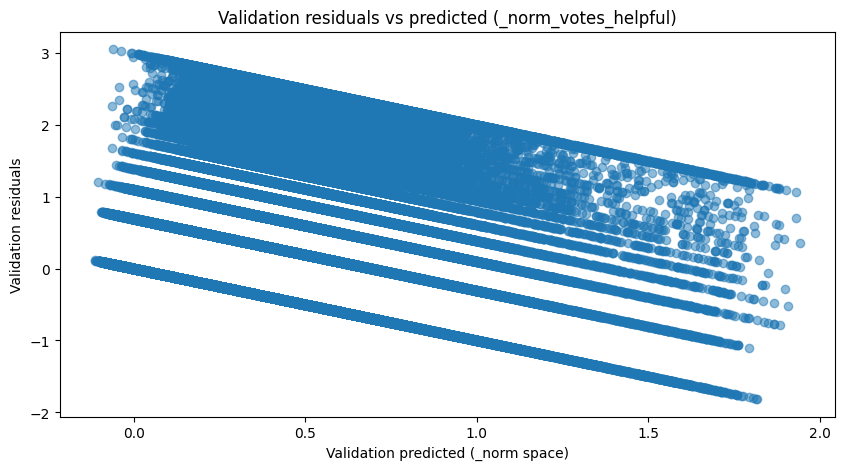

In [16]:
# plot val residuals
plt.figure(figsize=(10, 5))
plt.scatter(
    df_val['_norm_votes_helpful_pred'],
    df_val['_norm_votes_helpful'] - df_val['_norm_votes_helpful_pred'],
    alpha=0.5,
)
plt.xlabel('Validation predicted (_norm space)')
plt.ylabel('Validation residuals')
plt.title('Validation residuals vs predicted (_norm_votes_helpful)')
plt.show()

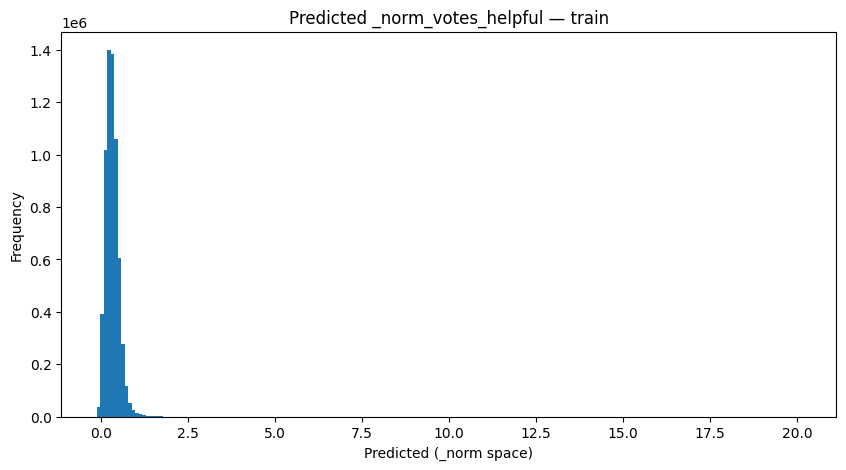

In [17]:
# histogram of predictions (_norm space)
plt.figure(figsize=(10, 5))
plt.hist(df_train['_norm_votes_helpful_pred'], bins=200)
plt.xlabel('Predicted (_norm space)')
plt.ylabel('Frequency')
plt.title('Predicted _norm_votes_helpful — train')
plt.show()

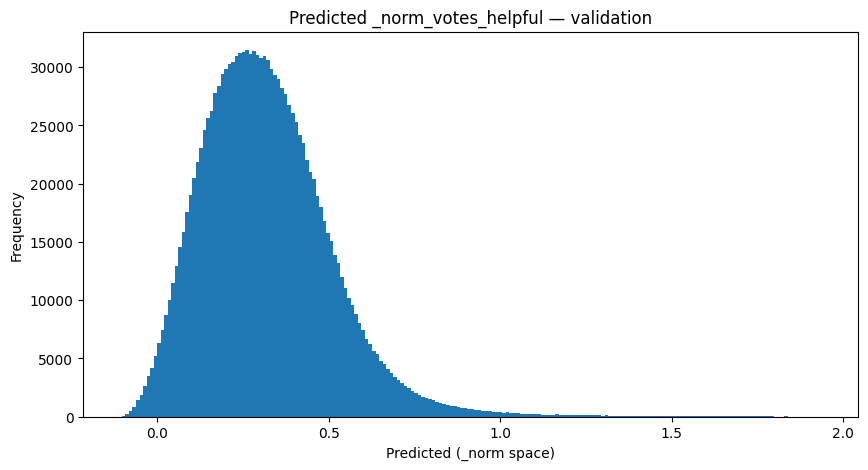

In [18]:
plt.figure(figsize=(10, 5))
plt.hist(df_val['_norm_votes_helpful_pred'], bins=200)
plt.xlabel('Predicted (_norm space)')
plt.ylabel('Frequency')
plt.title('Predicted _norm_votes_helpful — validation')
plt.show()

In [19]:
import plotly.graph_objects as go

# Create a bar plot of feature importances using Plotly
fig = go.Figure()

fig.add_trace(go.Bar(
    x=training_cols,
    y=linreg.coef_,
    marker_color='royalblue'
))

fig.update_layout(
    title='Most Important Features',
    xaxis_title='Features',
    yaxis_title='Coefficients',
    xaxis_tickangle=45,
    xaxis_tickfont=dict(size=10),
    margin=dict(b=150),  # Provide extra bottom margin for rotated labels
    height=500,
    width=1000
)

fig.show()

## 7) Three-feature restricted model


### Three features (normalized where the pipeline defines `_norm_*`)

Source concepts | Column in parquet
--- | ---
`author.num_reviews` | `_norm_author__num_reviews` (log1p in `DEFAULT_NORMALIZATION_RULES`)
`review_length_chars` | `review_length_chars` (no default `_norm_*` column)
`review_word_count` | `_norm_review_word_count` (log1p)

Target stays **`_norm_votes_helpful`** (same as the full model).

Section layout matches **Full Dataset Model** (artifact name → fit → **Train** → save bundle → **Residual and Error Diagnostics** → coefficient bar). Baselines (`all_zero`, `train_mean`, `empirical_random`) are computed once **above** **## Full Dataset Model**; this section only adds the restricted linreg row to `metrics_compare_3feat` for the combined evaluation below.


In [20]:
LINEAR_REGRESSION_3FEAT_MODEL_NAME = "votes_helpful_linreg_3feat.pkl"


In [21]:
# instantiate linear regression model (restricted feature set)
linreg_3 = LinearRegression()

training_cols_3 = [
    "_norm_author__num_reviews",
    "review_length_chars",
    "_norm_review_word_count",
]
linreg_3.fit(
    X=df_train[training_cols_3],
    y=df_train["_norm_votes_helpful"],
)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Train


In [22]:
# predict helpful votes (_norm space) — use distinct columns so full-model `_norm_votes_helpful_pred`
# and residual plots stay tied to the full feature set.
df_train["_norm_votes_helpful_pred_3feat"] = linreg_3.predict(df_train[training_cols_3])
df_val["_norm_votes_helpful_pred_3feat"] = linreg_3.predict(df_val[training_cols_3])

y_tr = df_train["_norm_votes_helpful"].to_numpy(dtype=float)
y_va = df_val["_norm_votes_helpful"].to_numpy(dtype=float)
lin3_tr = df_train["_norm_votes_helpful_pred_3feat"].to_numpy(dtype=float)
lin3_va = df_val["_norm_votes_helpful_pred_3feat"].to_numpy(dtype=float)

tr_m = regression_metrics(y_tr, lin3_tr)
va_m = regression_metrics(y_va, lin3_va)

row = {"model": "linreg_3feat_norm_reviews__len_chars__norm_word_count"}
for k, v in tr_m.items():
    row[f"train_{k}"] = v
for k, v in va_m.items():
    row[f"val_{k}"] = v

metrics_compare_3feat = pd.DataFrame([row])
numeric_cols = [c for c in metrics_compare_3feat.columns if c != "model"]
for c in numeric_cols:
    if c.startswith("val_"):
        k = c.replace("val_", "", 1)
        tc = f"train_{k}"
        if tc in metrics_compare_3feat.columns:
            metrics_compare_3feat[f"gap_{k}"] = metrics_compare_3feat[c] - metrics_compare_3feat[tc]

metrics_compare_3feat


,model,train_mae,train_mse,train_rmse,train_r2,train_mape_pct,train_spearman_rho,val_mae,val_mse,val_rmse,val_r2,val_mape_pct,val_spearman_rho,gap_mae,gap_mse,gap_rmse,gap_r2,gap_mape_pct,gap_spearman_rho
0,linreg_3feat_norm_reviews__len_chars__norm_wor...,0.414294,0.315352,0.561562,0.08119,2.059640e+09,0.242468,0.414487,0.315769,0.561933,0.081457,2.060285e+09,0.241827,0.000193,0.000418,0.000372,0.000267,644445.976801,-0.000641


In [23]:
# Save 3-feature bundle (same layout as full-model save; separate artifact name).
artifacts_root = REPO_ROOT / "artifacts"
model_dir = artifacts_root / "models" / "tabular"
model_dir.mkdir(parents=True, exist_ok=True)

model_bundle_3 = {
    "estimator": linreg_3,
    "feature_columns": training_cols_3,
    "target": "_norm_votes_helpful",
}
model_path_3 = model_dir / LINEAR_REGRESSION_3FEAT_MODEL_NAME
dump(model_bundle_3, model_path_3)
print(f"Saved 3-feature model bundle -> {model_path_3}")


Saved 3-feature model bundle -> /home/ryanr/workspace/steam_recommendations/artifacts/models/votes_helpful_linreg_3feat.pkl


### Residual and Error Diagnostics (3-feature model)

Same plots as **Residual and Error Diagnostics** for the full model, but using `_norm_votes_helpful_pred_3feat` so the full-model column `_norm_votes_helpful_pred` is unchanged.


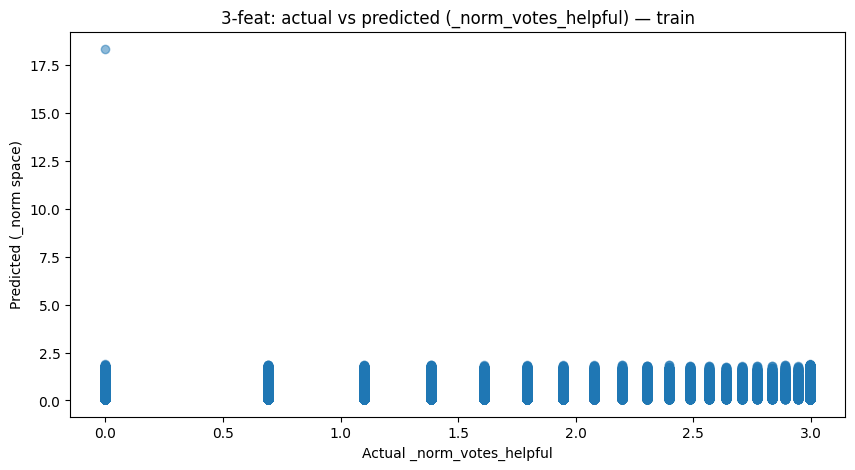

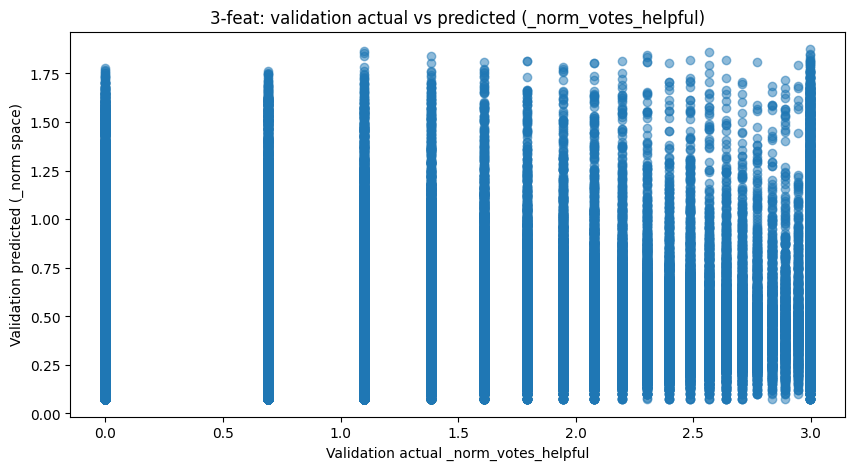

In [24]:
# Actual vs predicted (normalized target space) — 3-feature model
plt.figure(figsize=(10, 5))
plt.scatter(
    df_train["_norm_votes_helpful"],
    df_train["_norm_votes_helpful_pred_3feat"],
    alpha=0.5,
)
plt.xlabel("Actual _norm_votes_helpful")
plt.ylabel("Predicted (_norm space)")
plt.title("3-feat: actual vs predicted (_norm_votes_helpful) — train")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(
    df_val["_norm_votes_helpful"],
    df_val["_norm_votes_helpful_pred_3feat"],
    alpha=0.5,
)
plt.xlabel("Validation actual _norm_votes_helpful")
plt.ylabel("Validation predicted (_norm space)")
plt.title("3-feat: validation actual vs predicted (_norm_votes_helpful)")
plt.show()


In [25]:
# Record with highest predicted target in train (3-feature model, _norm space)
max_pred_idx_3 = df_train["_norm_votes_helpful_pred_3feat"].idxmax()
max_pred_record_3 = df_train.loc[max_pred_idx_3]
print("Record with highest _norm_votes_helpful_pred_3feat in df_train:")
print(max_pred_record_3)


Record with highest _norm_votes_helpful_pred_3feat in df_train:
review_id                                                                         33702432
app_id                                                                              379720
app_name                                                                              DOOM
author.steamid                                                           76561198320925817
review                                   [list][list][list][/list][/list][/list] \n[quo...
recommended                                                                              0
votes_helpful                                                                            0
author.num_games_owned                                                                 103
author.num_reviews                                                                      10
author.playtime_last_two_weeks                                                         0.0
author.playtime_at_review 

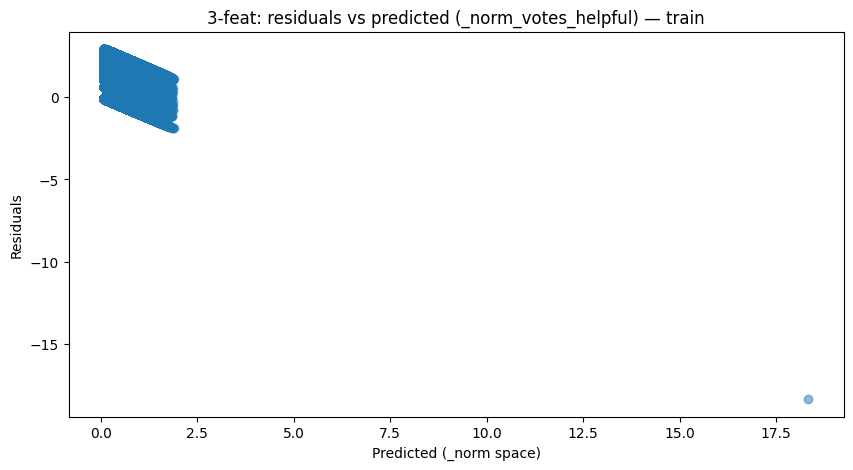

In [26]:
# Residuals vs predicted — train (3-feature)
plt.figure(figsize=(10, 5))
plt.scatter(
    df_train["_norm_votes_helpful_pred_3feat"],
    df_train["_norm_votes_helpful"] - df_train["_norm_votes_helpful_pred_3feat"],
    alpha=0.5,
)
plt.xlabel("Predicted (_norm space)")
plt.ylabel("Residuals")
plt.title("3-feat: residuals vs predicted (_norm_votes_helpful) — train")
plt.show()


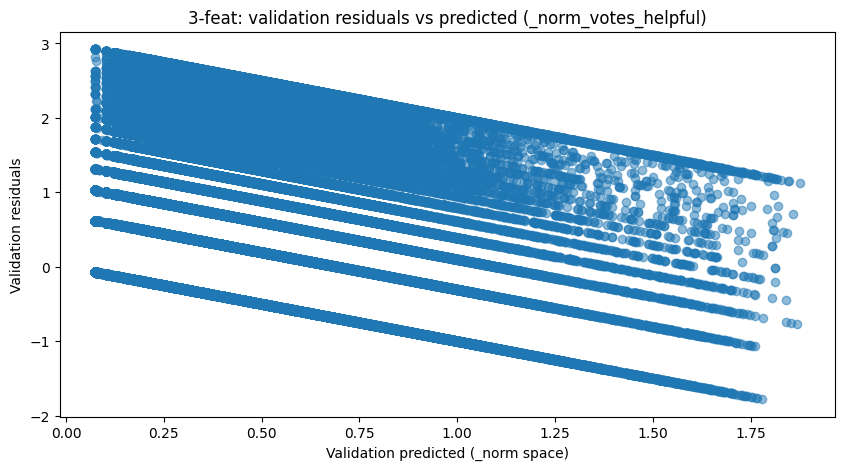

In [27]:
# Validation residuals vs predicted (3-feature)
plt.figure(figsize=(10, 5))
plt.scatter(
    df_val["_norm_votes_helpful_pred_3feat"],
    df_val["_norm_votes_helpful"] - df_val["_norm_votes_helpful_pred_3feat"],
    alpha=0.5,
)
plt.xlabel("Validation predicted (_norm space)")
plt.ylabel("Validation residuals")
plt.title("3-feat: validation residuals vs predicted (_norm_votes_helpful)")
plt.show()


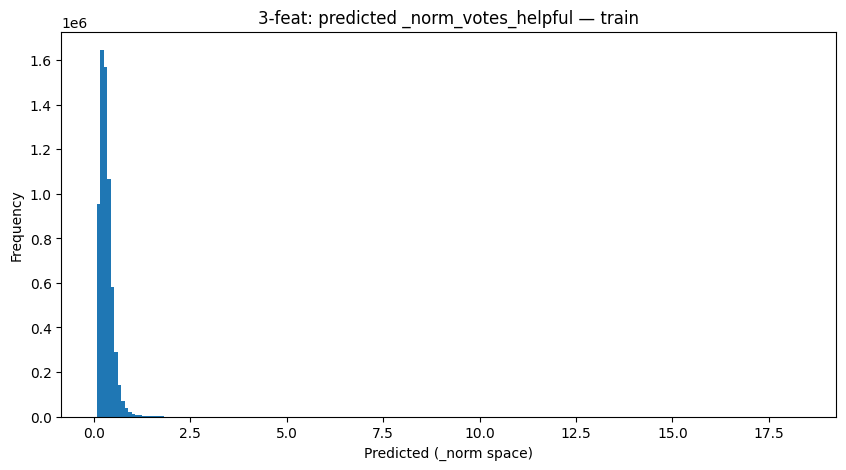

In [28]:
# Histogram of predictions — train (3-feature)
plt.figure(figsize=(10, 5))
plt.hist(df_train["_norm_votes_helpful_pred_3feat"], bins=200)
plt.xlabel("Predicted (_norm space)")
plt.ylabel("Frequency")
plt.title("3-feat: predicted _norm_votes_helpful — train")
plt.show()


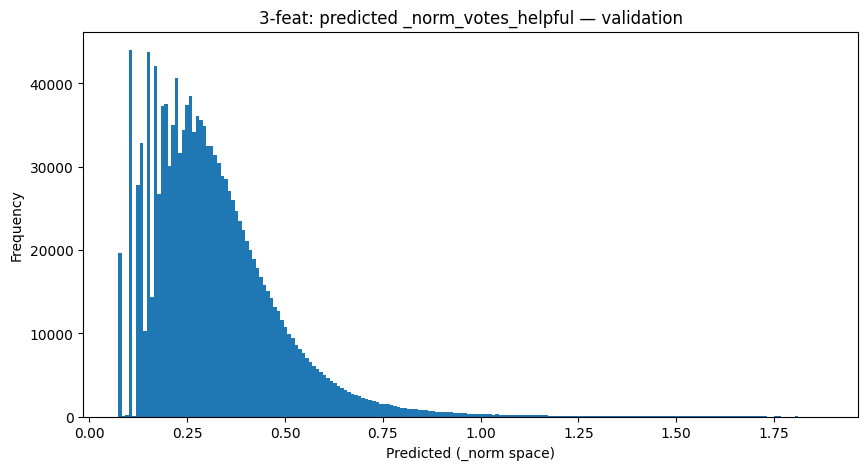

In [29]:
plt.figure(figsize=(10, 5))
plt.hist(df_val["_norm_votes_helpful_pred_3feat"], bins=200)
plt.xlabel("Predicted (_norm space)")
plt.ylabel("Frequency")
plt.title("3-feat: predicted _norm_votes_helpful — validation")
plt.show()


In [30]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Bar(
            x=training_cols_3,
            y=linreg_3.coef_,
            marker_color="teal",
            text=[f"{c:.4g}" for c in linreg_3.coef_],
            textposition="outside",
        )
    ]
)
fig.update_layout(
    title="Coefficients — 3-feature model (norm review count / raw length / norm word count)",
    xaxis_title="Feature",
    yaxis_title="Coefficient",
    xaxis_tickangle=45,
    height=480,
    width=720,
    margin=dict(b=120),
)
fig.show()



# Metric evaluation

In [31]:
# All models in one table: baselines + full linreg + optional 3-feature linreg
_metric_parts = [metrics_compare]
if "metrics_compare_3feat" in globals():
    _metric_parts.append(metrics_compare_3feat)
metrics_compare_all = pd.concat(_metric_parts, ignore_index=True)
metrics_compare_all


,model,train_mae,train_mse,train_rmse,train_r2,train_mape_pct,train_spearman_rho,val_mae,val_mse,val_rmse,val_r2,val_mape_pct,val_spearman_rho,gap_mae,gap_mse,gap_rmse,gap_r2,gap_mape_pct,gap_spearman_rho
0,all_zero,0.318910,0.444921,0.667024,-0.296325,2.988793e+01,NaN,0.318993,0.445528,0.667479,-2.960006e-01,2.987633e+01,NaN,0.000083,0.000607,0.000455,3.244519e-04,-1.159781e-02,NaN
1,train_mean,0.447189,0.343217,0.585848,0.000000,2.235947e+09,NaN,0.447346,0.343772,0.586320,-1.987587e-08,2.236317e+09,NaN,0.000157,0.000554,0.000473,-1.987587e-08,3.698662e+05,NaN
2,empirical_random,0.495788,0.686687,0.828666,-1.000736,2.234892e+09,0.000003,0.495974,0.685874,0.828175,-9.951428e-01,2.236034e+09,-0.001435,0.000186,-0.000814,-0.000491,5.592866e-03,1.141814e+06,-0.001438
3,linreg_full_dataset,0.401852,0.307131,0.554194,0.105142,2.000357e+09,0.302910,0.402217,0.307647,0.554659,1.050843e-01,2.002613e+09,0.301636,0.000365,0.000516,0.000465,-5.725168e-05,2.256252e+06,-0.001273
4,linreg_3feat_norm_reviews__len_chars__norm_wor...,0.414294,0.315352,0.561562,0.081190,2.059640e+09,0.242468,0.414487,0.315769,0.561933,8.145697e-02,2.060285e+09,0.241827,0.000193,0.000418,0.000372,2.670448e-04,6.444460e+05,-0.000641


In [32]:
import plotly.graph_objects as go
import plotly.subplots as sp

# Bar chart comparing main regression metrics for each model using Plotly
metrics_to_plot = ['mae', 'mse', 'rmse', 'r2']
n_metrics = len(metrics_to_plot)

fig = sp.make_subplots(
    rows=1, cols=n_metrics, 
    subplot_titles=[m.upper() for m in metrics_to_plot]
)

for i, metric in enumerate(metrics_to_plot):
    train_metric = f"train_{metric}"
    val_metric = f"val_{metric}"

    fig.add_trace(
        go.Bar(
            x=metrics_compare_all['model'],
            y=metrics_compare_all[train_metric],
            name='Train',
            marker_color='steelblue',
            text=metrics_compare_all[train_metric].round(3),
            textposition='auto'
        ),
        row=1, col=i+1
    )
    fig.add_trace(
        go.Bar(
            x=metrics_compare_all['model'],
            y=metrics_compare_all[val_metric],
            name='Val',
            marker_color='darkorange',
            text=metrics_compare_all[val_metric].round(3),
            textposition='auto'
        ),
        row=1, col=i+1
    )
    # Only show legend once in the first subplot.
    fig.update_traces(showlegend=(i == 0), row=1, col=i+1)
    fig.update_xaxes(title_text="Model", tickangle=45, row=1, col=i+1)
    fig.update_yaxes(title_text=metric.upper(), row=1, col=i+1)


fig.update_layout(
    barmode='group',
    width=4 * n_metrics * 100,  # Dynamic width
    height=700,
    title_text="Regression metrics — all models (baselines + linreg + 3-feat)",
    legend_title_text="Split",
    margin=dict(t=60, l=20, r=20, b=50)
)
fig.show()

In [33]:
# gap_* columns are validation − training (same metric), from metrics_compare_all.
# For errors (MAE/MSE/RMSE), higher is worse: positive gap ⇒ worse on validation.
# For R², higher is better: positive gap ⇒ better on validation.

import plotly.graph_objs as go
from plotly.subplots import make_subplots

gap_metrics = ['gap_mae', 'gap_mse', 'gap_rmse', 'gap_r2']

fig = make_subplots(
    rows=1, cols=len(gap_metrics),
    subplot_titles=[m.upper() for m in gap_metrics]
)

for i, metric in enumerate(gap_metrics):
    fig.add_trace(
        go.Bar(
            x=metrics_compare_all['model'],
            y=metrics_compare_all[metric],
            marker_color='mediumslateblue',
            text=metrics_compare_all[metric].round(4),
            textposition='outside',  # Move text above bars to prevent overlap
            name=metric.upper(),
        ),
        row=1, col=i+1
    )
    fig.update_xaxes(title_text="Model", tickangle=45, row=1, col=i+1)
    fig.update_yaxes(title_text=metric.upper(), row=1, col=i+1)

fig.update_layout(
    showlegend=False,
    width=4 * len(gap_metrics) * 120,  # Make each subplot a bit wider to help spacing
    height=740,  # Slightly higher for safety
    title_text="Gap metrics (val − train) — all models",
    margin=dict(t=160, l=20, r=20, b=60)  # More top margin to avoid overlap
)

fig.show()

print(
    """Interpretation (gap = val − train):
    MAE/MSE/RMSE: positive ⇒ higher error on val (often overfitting).
    R²: positive ⇒ higher R² on val.
    """
)

Interpretation (gap = val − train):
    MAE/MSE/RMSE: positive ⇒ higher error on val (often overfitting).
    R²: positive ⇒ higher R² on val.
    


# Export metrics

Run **after** **Metric evaluation** so `metrics_compare_all` exists. The CSV matches the combined table in the charts (baselines + full linreg + 3-feature row when that section ran). To add experiments, extend the `_metric_parts` list in the metric-evaluation cell or adjust the fallback `concat` below.

In [36]:
METRIC_FILENAME

'votes_helpful_metrics.csv'

In [38]:
from pathlib import Path

artifacts_root = REPO_ROOT / "artifacts"
metrics_dir = artifacts_root / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

if "metrics_compare_all" in globals():
    metrics_export = metrics_compare_all
else:
    _parts = [metrics_compare]
    if "metrics_compare_3feat" in globals():
        _parts.append(metrics_compare_3feat)
    metrics_export = pd.concat(_parts, ignore_index=True)

out_path = metrics_dir / f"{METRIC_FILENAME}"
metrics_export.to_csv(out_path, index=False)
print(f"Wrote metrics ({len(metrics_export)} rows) -> {out_path}")


Wrote metrics (5 rows) -> /home/ryanr/workspace/steam_recommendations/artifacts/metrics/votes_helpful_metrics.csv
